In [17]:
import pandas as pd
import scipy.stats as stats

pd.set_option('display.max_columns', None)

from sklearn.ensemble import RandomForestRegressor
import xgboost
import catboost

import torch

import numpy as np
import seaborn as sns
sns.set_style("whitegrid")

import matplotlib.pyplot as plt


In [18]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [19]:
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..')) 

sys.path.append(os.path.join(project_root, 'Scripts'))

from model_utils.data import *
from data_utils.colors_config import *
from data_utils.processing import *
from model_utils.trainer import *
from model_utils.selector import *


current_dir = os.path.dirname(os.path.abspath('__file__'))
root_dir = os.path.abspath(os.path.join(current_dir, '../../'))

if root_dir not in sys.path:
    sys.path.append(root_dir)

import config

In [20]:
set_seed(77)
data = pd.read_parquet(config.FPL_DATA_PATH)

In [21]:
data.head()

,transfers_in,position,element,gw,code,season,transfers_balance,was_home,name,selected,transfers_out,value,transfers_trend,kickoff_time,total_points,bonus_ema_8,bps_ema_8,value_ema_8,threat_ema_8,transfers_out_ema_8,transfers_balance_ema_8,transfers_in_ema_8,transfers_trend_ema_8,yellow_cards_ema_8,xg_conceded_per_90_ema_8,xg_involvements_per_90_ema_8,xg_per_90_ema_8,xa_per_90_ema_8,own_goals_ema_8,assists_ema_8,saves_ema_8,penalties_saved_ema_8,xp_ema_8,penalties_missed_ema_8,team_h_score_ema_8,xa_ema_8,team_a_score_ema_8,red_cards_ema_8,total_points_ema_8,transfers_out_lagged_1,transfers_balance_lagged_1,transfers_in_lagged_1,transfers_trend_lagged_1,xg_conceded_per_90_lagged_1,xg_involvements_per_90_lagged_1,xg_per_90_lagged_1,xa_per_90_lagged_1,own_goals_lagged_1,penalties_saved_lagged_1,xp_lagged_1,team_h_score_lagged_1,team_a_score_lagged_1,red_cards_lagged_1,total_points_lagged_1
0,0.0,GK,760.0,32.0,11948.0,2223.0,0.0,False,Andy Lonergan,0.0,0.0,4.0,0.000000,2023-04-22T14:00:00,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,18.0,GK,760.0,33.0,11948.0,2223.0,17.0,True,Andy Lonergan,33.0,1.0,4.0,0.515152,2023-04-27T18:45:00,0.0,0.0,0.0,4.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.500000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.5,0.0,0.0,0.0,0.0
2,25.0,GK,760.0,34.0,11948.0,2223.0,19.0,False,Andy Lonergan,84.0,6.0,4.0,0.226190,2023-05-01T19:00:00,0.0,0.0,0.0,4.0,0.0,0.222222,3.777778,4.000000,0.114478,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.055556,0.0,0.222222,0.0,0.888889,0.0,0.0,1.0,17.0,18.0,0.515152,0.0,0.0,0.0,0.0,0.0,0.0,-0.5,1.0,4.0,0.0,0.0
3,32.0,GK,760.0,35.0,11948.0,2223.0,11.0,False,Andy Lonergan,111.0,21.0,4.0,0.099099,2023-05-08T16:30:00,0.0,0.0,0.0,4.0,0.0,1.506173,7.160494,8.666667,0.139303,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.820988,0.0,0.617284,0.0,1.135802,0.0,0.0,6.0,19.0,25.0,0.226190,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0
4,22.0,GK,760.0,36.0,11948.0,2223.0,-3.0,True,Andy Lonergan,134.0,25.0,4.0,-0.022388,2023-05-14T13:00:00,0.0,0.0,0.0,4.0,0.0,5.838134,8.013717,13.851852,0.130369,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.638546,0.0,0.702332,0.0,1.994513,0.0,0.0,21.0,11.0,32.0,0.099099,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,0.0,0.0


In [26]:
cols_map = colors_config.FEATURES_GROUP
cols_map.keys()

dict_keys(['target', 'id_cols', 'static_cols', 'fpl_cols', 'perf_cols', 'pre_game_cols'])

In [27]:
num_cols = [c for c in data.columns if "ema" in c or "lagg" in c]
len(num_cols)

39

In [28]:
static_cols = [f"{c}_id" for c in cols_map["static_cols"] if c not in  ["was_home", "team_strength", "player_id"]] + ["was_home", "team_strength"]

In [29]:
fpl_data_pipe = FPLDataPipe(num_cols=num_cols,
                            cat_cols=[c for c in cols_map.get("static_cols") if c in data.columns])

data_splits = train_test_split(data)
pipeline_state = (data_splits, fpl_data_pipe.preprocessor)

In [31]:
from dataclasses import dataclass
from typing import Any, Dict

@dataclass
class ModelConfig:
    model: Any
    param_grid: Dict[str, Any]


@dataclass
class ParamGrid:
    catboost: Dict[str, Any]
    xgboost: Dict[str, Any]


param_grid = ParamGrid(
    catboost={
        "iterations": stats.randint(300, 1500),
        "depth": stats.randint(4, 10),
        "learning_rate": stats.uniform(0.01, 0.05),
        "l2_leaf_reg": stats.uniform(1.0, 8.0),
        "bagging_temperature": stats.uniform(0.0, 5.0),
        "random_strength": stats.uniform(0.5, 5.0),
        "border_count": stats.randint(32, 255),
    },
    
    xgboost={
        "n_estimators": stats.randint(300, 1200),
        "max_depth": stats.randint(3, 10),
        "learning_rate": stats.uniform(0.01, 0.05),
        "subsample": stats.uniform(0.7, 0.3),
        "colsample_bytree": stats.uniform(0.6, 0.3),
        "min_child_weight": stats.randint(1, 10),
        "gamma": stats.uniform(0.0, 5.0),
        "reg_alpha": stats.uniform(0.0, 2.0),
        "reg_lambda": stats.uniform(0.5, 3.0),
    }
)

model_registry = {
    "catboost": ModelConfig(
        model=catboost.CatBoostRegressor(random_state=77, 
                                loss_function="RMSE", 
                                task_type="GPU", 
                                verbose=0),
        param_grid=param_grid.catboost
    ),
    "xgboost": ModelConfig(
        model=xgboost.XGBRegressor(random_state=77, 
                            objective='reg:squarederror', 
                            eval_metric='rmse', 
                            device="cuda"),
        param_grid=param_grid.xgboost
    )
}

In [41]:
def split_xy(pipeline_state: tuple):
    data_splits, preprocessor = pipeline_state
    X_train = preprocessor.fit_transform(data_splits["X_train"]).drop(columns=["date"])
    X_valid = preprocessor.transform(data_splits["X_valid"]).drop(columns=["date"])
    X_test  = preprocessor.transform(data_splits["X_test"]).drop(columns=["date"])

    y_train = data_splits["y_train"]
    y_valid = data_splits["y_valid"]
    y_test  = data_splits["y_test"]

    return (X_train, X_valid, X_test, y_train, y_valid, y_test)



In [52]:
def train_models(model_registry: dict, pipeline_state: tuple):
    data_splits, preprocessor = pipeline_state
    selector = ModelSelector(random_state=77)

    results_list = []
    params = {}


    for name, cfg in model_registry.items():

        model = cfg.model
        grid = cfg.param_grid


        if isinstance(model, CatBoostRegressor):
            X_train, y_train = data_splits.get("X_train"), data_splits.get("y_train") 
            cat_features = list(X_train.select_dtypes(include=["object", "string"]).columns)
            
        else:
            cat_features = None
            X_train, y_train = data_splits.get("X_train"), data_splits.get("y_train") 
            X_train, y_train = preprocessor(X_train), preprocessor(y_train)
        
        print(X_train.shape, y_train.shape)
        df_results, best_models_map = selector.params_search(
            models=[model],
            models_names=[name],
            params_grid=[grid],
            X_train=X_train,
            y_train=y_train,
            cv=5,
            n_iter=30,
            scoring="neg_mean_squared_error",
            cat_features=cat_features
        )

        results_list.append(df_results)
        params[name] = best_models_map[name]

    return pd.concat(results_list, axis=0), params

In [53]:
results, params = train_models(model_registry=model_registry, pipeline_state=pipeline_state)

(56230, 53) (56230,)
Fitting 5 folds for each of 30 candidates, totalling 150 fits


KeyboardInterrupt: 

In [ ]:
results 

,data,name,cv_mean_neg_mean_squared_error,best_params,mse,mae,r2
0,train,XGBRegressor,-3.639180,"{'colsample_bytree': 0.6291883211349544, 'gamm...",3.420707,0.956219,0.366559
0,train,CatBoostRegressor,-3.641223,"{'bagging_temperature': 1.3334891660135422, 'b...",3.559004,0.973432,0.340949


In [ ]:
best_models_map

{'CatBoostRegressor': CatBoostRegressor(bagging_temperature=np.float64(1.3334891660135422), border_count=232, depth=5, devices='cuda', iterations=1364, l2_leaf_reg=np.float64(1.7904161038533077), learning_rate=np.float64(0.011340981834987454), loss_function='RMSE', random_state=77, random_strength=np.float64(4.009155453699757), verbose=0)}

{'XGBRegressor': XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=np.float64(0.6291883211349544), device='cuda',
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='rmse', feature_types=None, feature_weights=None,
              gamma=np.float64(2.567468705523486), grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=np.float64(0.01043651989437089), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=463, n_jobs=None,
              num_parallel_tree=None, ...),
 'CatBoostRegressor': CatBoostRegressor(bagging_temperature=np.float64(1.3334891660135422), border_count=232, depth=5, 

In [ ]:
eval_results, y_preds = selector.evaluate(best_models_map[0], X_valid, y_valid)

In [ ]:
eval_results

,data,model_name,mse,mae,r2
0,test,CatBoostRegressor,3.711553,1.007346,0.304854


In [ ]:
trained_models = {c: best_params.get(c) for c in model_names}

AttributeError: 'NoneType' object has no attribute 'feature_importances_'

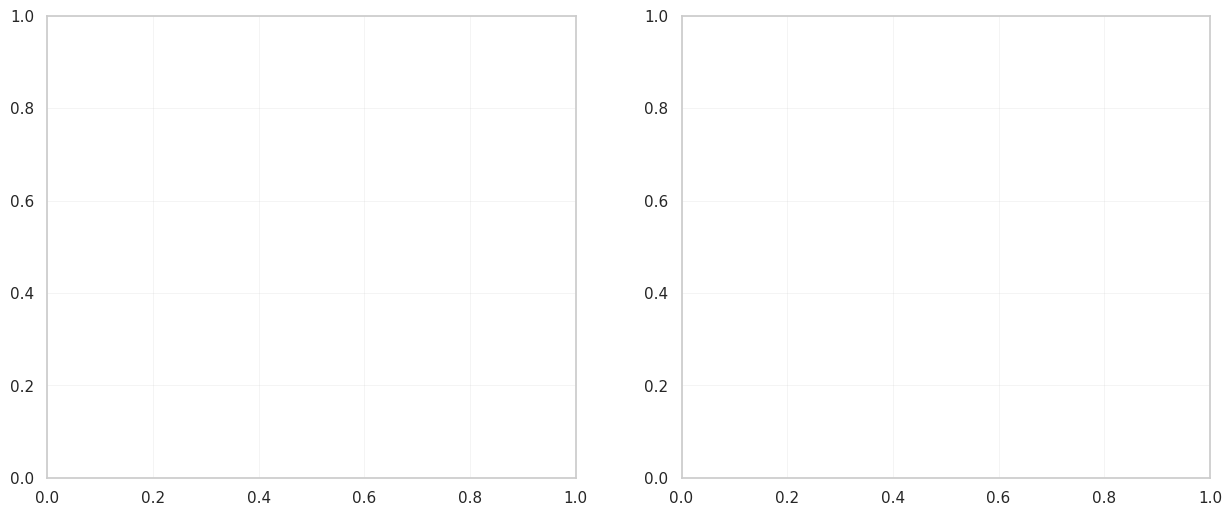

In [ ]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(15, 6), sharex=True)

for idx, (model_name, model) in enumerate(trained_models.items()):
    sns.barplot(data=pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10), ax=ax[idx], orient="h", color="lightblue")
    ax[idx].set_title(f"Feature Importances - {model_name}", fontsize=14)
plt.tight_layout()

In [ ]:
preds = {}
for model_name, model in trained_models.items():
    preds[model_name] = model.predict(X_test)

preds = pd.DataFrame(preds, index=X_test.index)
final_results = pd.concat([data.loc[X_test.index, ["name", "season", "total_points", "gw"]], preds], axis=1)

In [ ]:
final_results.total_points.max(), final_results.XGBRegressor.max()

(np.float64(24.0), np.float32(17.585209))

In [ ]:
final_results.loc[(final_results.total_points -  final_results.XGBRegressor).apply(np.abs).sort_values(ascending=False).index, :]

,name,season,total_points,gw,XGBRegressor
47202,James Justin,2526.0,19.0,33.0,0.647565
67172,Jurriën Timber,2526.0,24.0,2.0,5.892984
34736,Mikel Merino Zazón,2526.0,0.0,2.0,17.376766
21708,Bruno Borges Fernandes,2526.0,0.0,18.0,17.296648
59077,Jørgen Strand Larsen,2526.0,0.0,31.0,16.852674
...,...,...,...,...,...
80162,Blondy Nna Noukeu,2526.0,0.0,5.0,-0.000072
87346,Zak Johnson,2526.0,0.0,5.0,-0.000072
70556,Levi Samuels Colwill,2526.0,0.0,10.0,-0.000030
64664,Jakub Kiwior,2526.0,0.0,8.0,-0.000030


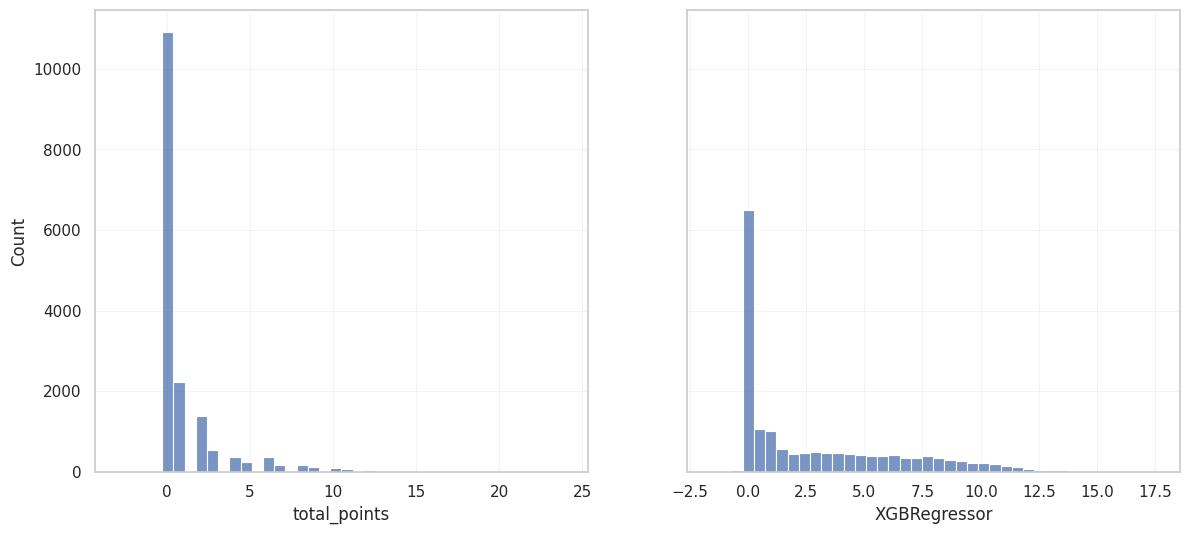

In [ ]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(14, 6), sharey=True)
for i, col in enumerate(["total_points", "XGBRegressor"]):
    sns.histplot(data=final_results[col], ax=ax[i], bins=40)

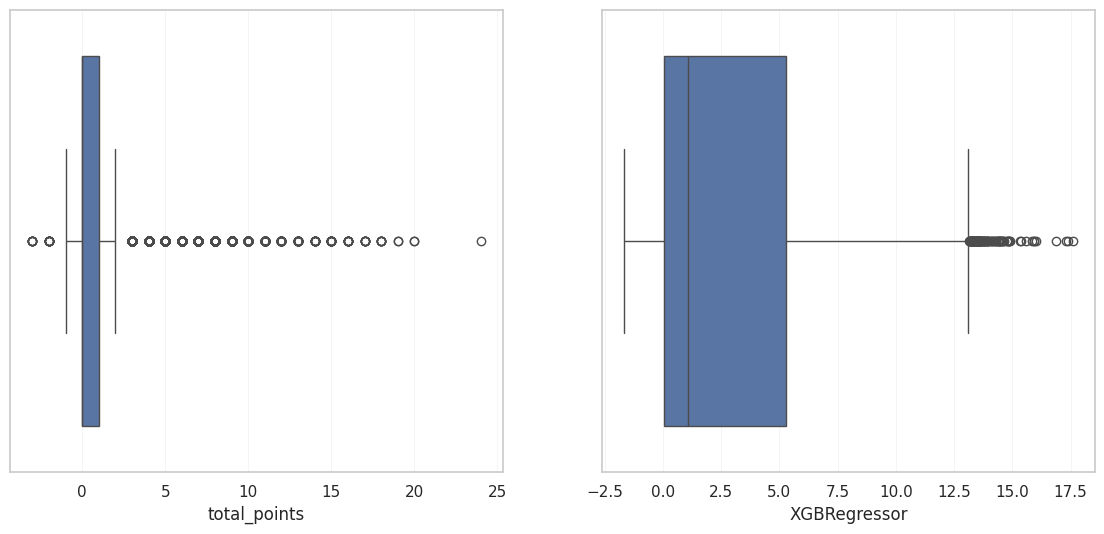

In [ ]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(14, 6))
for i, col in enumerate(["total_points", "XGBRegressor"]):
    sns.boxplot(data=final_results[col], ax=ax[i], orient="h")

In [ ]:
final_results.sample(10)

,name,season,total_points,gw,XGBRegressor
97335,Caleb Kporha,2526.0,0.0,11.0,-0.001169
45010,Florentino Ibrain Morris Luís,2526.0,8.0,8.0,0.658461
100207,Charlie Stevens,2526.0,0.0,24.0,0.088231
77257,Hjalmar Ekdal,2526.0,0.0,29.0,8.349735
55864,Bafodé Diakité,2526.0,0.0,32.0,7.176540
47115,Michael Obafemi,2526.0,0.0,28.0,0.009238
87884,Lamare Bogarde,2526.0,1.0,30.0,7.702516
61245,Matheus Santos Carneiro da Cunha,2526.0,3.0,25.0,7.416895
76933,Maxime Estève,2526.0,0.0,17.0,1.016374
88702,Max Weiß,2526.0,0.0,24.0,0.601291


In [ ]:
final_results[final_results.name=="Erling Haaland"].tail()

,name,season,total_points,gw,XGBRegressor


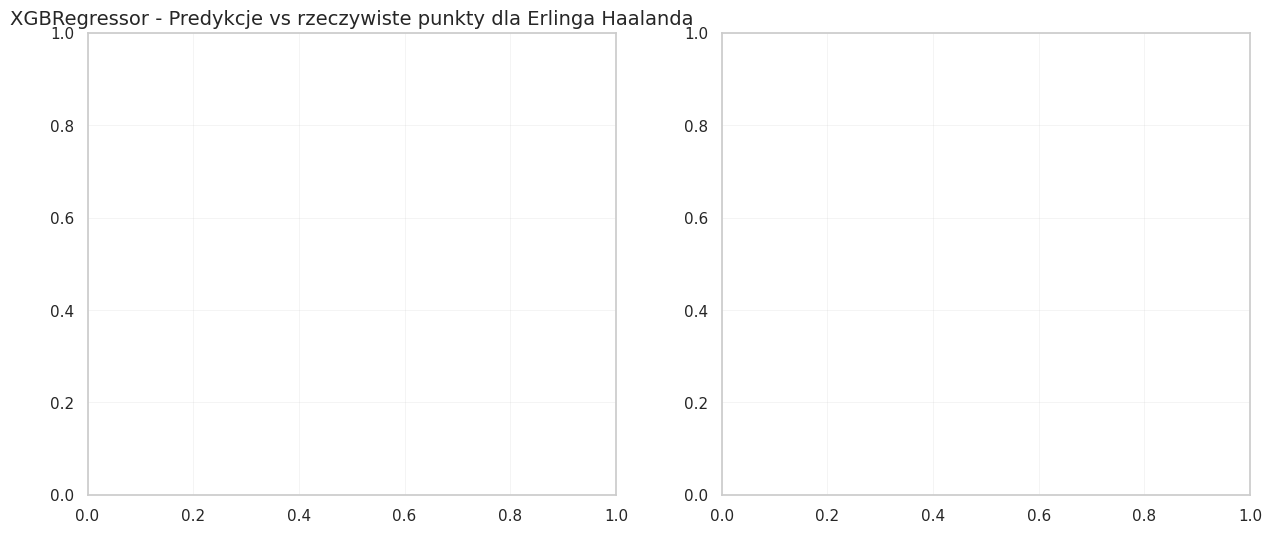

In [ ]:

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(15, 6), sharex=True)
for model_name in model_names:
    sns.scatterplot(data=final_results.loc[final_results.name=="Erling Haaland", ["total_points", model_name]].reset_index(drop=True), ax=ax[model_names.index(model_name)], color="steelblue")
    ax[model_names.index(model_name)].set_title(f"{model_name} - Predykcje vs rzeczywiste punkty dla Erlinga Haalanda", fontsize=14);



In [ ]:
final_results.loc[final_results.xgb==final_results.xgb.max()]

AttributeError: 'DataFrame' object has no attribute 'xgb'

In [ ]:
final_results.loc[final_results.rf==final_results.rf.max()]

AttributeError: 'DataFrame' object has no attribute 'rf'